# Classical Solver for TSP-CS (City Selection)

In [ ]:
!pip install ortools

In [33]:
from ortools.sat.python import cp_model
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [66]:
def plot_full_network_graph(distance_matrix, node_values):
    n = len(distance_matrix)
    G = nx.Graph()

    for i in range(n):
        for j in range(i + 1, n):
            dist = distance_matrix[i][j]
            G.add_edge(i, j, weight=dist)

    labels = {i: f"{i}\n(${node_values[i]}$)" for i in range(n)}

    pos = nx.circular_layout(G, scale=2)

    plt.figure(figsize=(12, 10))

    # --- Nodes ---
    node_colors = ['gold' if i == 0 else 'lightgreen' for i in range(n)]
    nx.draw_networkx_nodes(G, pos, node_size=1500, node_color=node_colors, edgecolors='black')
    nx.draw_networkx_labels(G, pos, labels=labels, font_size=10, font_weight='bold')

    # --- Links ---
    nx.draw_networkx_edges(G, pos, width=1.2, alpha=0.3, edge_color='gray')

    # --- Weights (Distances) ---
    edge_costs = nx.get_edge_attributes(G, 'weight')

    nx.draw_networkx_edge_labels(
        G, pos,
        edge_labels=edge_costs,
        label_pos=0.7,
        font_size=9,
        font_color='darkred',
        rotate=False,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=0.5)
    )

    plt.title("Network Map: Each link shows the fuel cost to jump between debris", pad=20)
    plt.axis('off')
    plt.show()

In [67]:
def plot_debris_graph(distance_matrix, tour, debris_values):
    if not tour:
        return

    n = len(distance_matrix)
    G = nx.DiGraph()
    pos = nx.spring_layout(range(n), seed=42)

    visited_nodes = set(tour)
    unvisited_nodes = [i for i in range(n) if i not in visited_nodes]
    edges = [(tour[i], tour[i+1]) for i in range(len(tour)-1)]

    plt.figure(figsize=(12, 8))

    # Draw nodes
    nx.draw_networkx_nodes(G, pos, nodelist=unvisited_nodes, node_color='#ffaaaa',
                           node_size=600, label='Unvisited Debris')
    nx.draw_networkx_nodes(G, pos, nodelist=list(visited_nodes), node_color='#aaffaa',
                           node_size=800, label='Collected Debris')
    nx.draw_networkx_nodes(G, pos, nodelist=[0], node_color='#ffee00',
                           node_size=1000, label='Starting Satellite')

    # Draw edges (Path)
    nx.draw_networkx_edges(G, pos, edgelist=edges, width=2.5, edge_color='#2255ff',
                           arrowstyle='-|>', arrowsize=25)

    # Labels
    labels = {i: f"ID:{i}\nVal:{debris_values[i]}" for i in range(n)}
    nx.draw_networkx_labels(G, pos, labels, font_size=9, font_weight='bold')

    plt.title("Satellite Mission: TSP-City Selection (Open Path)")
    plt.legend(scatterpoints=1)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

In [64]:
def solve_tsp_city_selection(distance_matrix, debris_values, fuel_limit):
    n = len(distance_matrix)
    model = cp_model.CpModel()
    solver = cp_model.CpSolver()

    # --- VARIABLES ---
    x = {}
    for i in range(n):
        for j in range(n):
            if i != j:
                x[i, j] = model.NewBoolVar(f"x_{i}_{j}")

    # y[i] = 1 if debris i is visited
    y = [model.NewBoolVar(f"y_{i}") for i in range(n)]

    # --- CONSTRAINTS ---
    # 1. Starting point (Node 0) is always visited
    model.Add(y[0] == 1)

    # 2. Linkage: y[i] is 1 if and only if there is an incoming edge to i
    for i in range(1, n):
        model.Add(y[i] == sum(x[j, i] for j in range(n) if i != j))

    # 3. Flow Conservation & Path Logic
    for i in range(n):
        out_flow = sum(x[i, j] for j in range(n) if i != j)
        in_flow = sum(x[j, i] for j in range(n) if i != j)

        # Each node can be exited at most once
        model.Add(out_flow <= 1)

        if i == 0:
            model.Add(out_flow <= 1) # Start can exit once
            model.Add(in_flow == 0)  # Start cannot be entered (Open Path)
        else:
            # For any node that isn't the start:
            # If you enter it, you can either stay there (last node) or leave.
            # Therefore: In-flow >= Out-flow
            model.Add(in_flow >= out_flow)

    # 4. Fuel Constraint (L)
    total_cost = sum(distance_matrix[i][j] * x[i, j]
                     for i in range(n) for j in range(n) if i != j)
    model.Add(total_cost <= fuel_limit)

    # 5. Subtour Elimination (MTZ)
    u = [model.NewIntVar(0, n, f"u_{i}") for i in range(n)]
    for i in range(n):
        for j in range(1, n):
            if i != j:
                model.Add(u[j] >= u[i] + 1).OnlyEnforceIf(x[i, j])

    # --- OBJECTIVE ---
    model.Maximize(sum(debris_values[i] * y[i] for i in range(n)))

    # --- SOLVE ---
    status = solver.Solve(model)

    if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
        # Path reconstruction
        current_node = 0
        tour = [0]
        while True:
            found_next = False
            for j in range(n):
                if (current_node, j) in x and solver.Value(x[current_node, j]) == 1:
                    tour.append(j)
                    current_node = j
                    found_next = True
                    break
            if not found_next:
                break

        actual_value = sum(debris_values[i] for i in tour)
        print(f"Solver Status: {solver.StatusName(status)}")
        print(f"Total Value: {solver.ObjectiveValue()}")
        print(f"Fuel Limit: {fuel_limit}")
        print(f"Fuel Used: {sum(distance_matrix[tour[i]][tour[i+1]] for i in range(len(tour)-1))}")
        print(f"Optimal Path: {tour}")
        return tour
    return None

Solver Status: OPTIMAL
Total Value: 90.0
Fuel Limit: 40
Fuel Used: 36
Optimal Path: [0, 1, 2, 3]


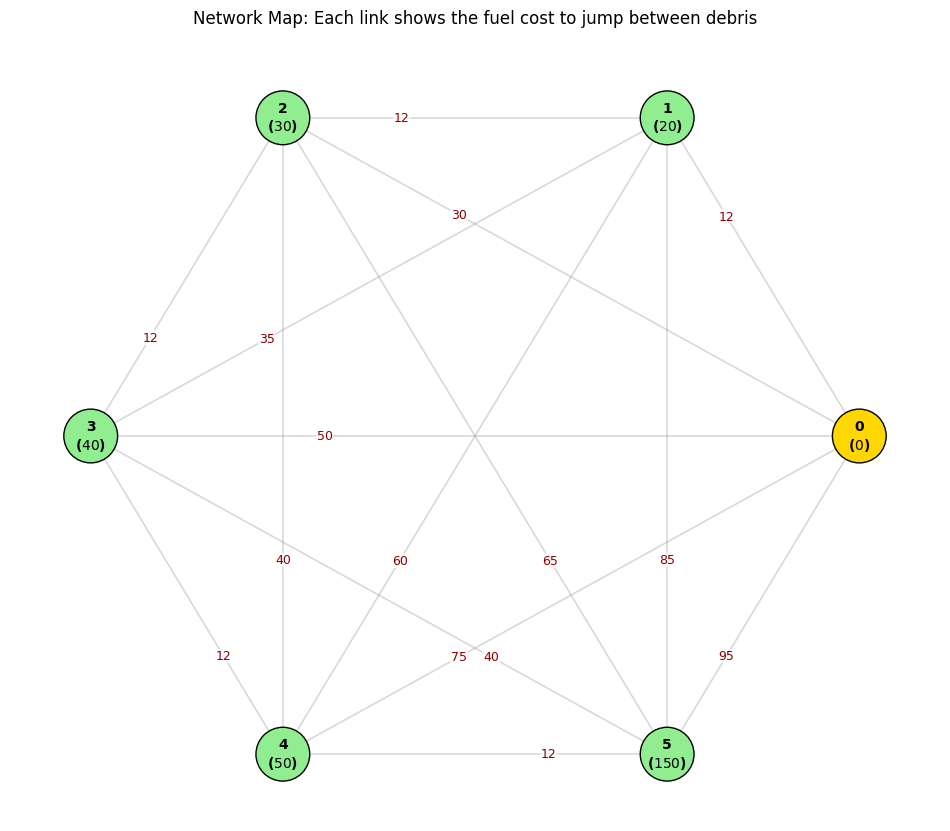

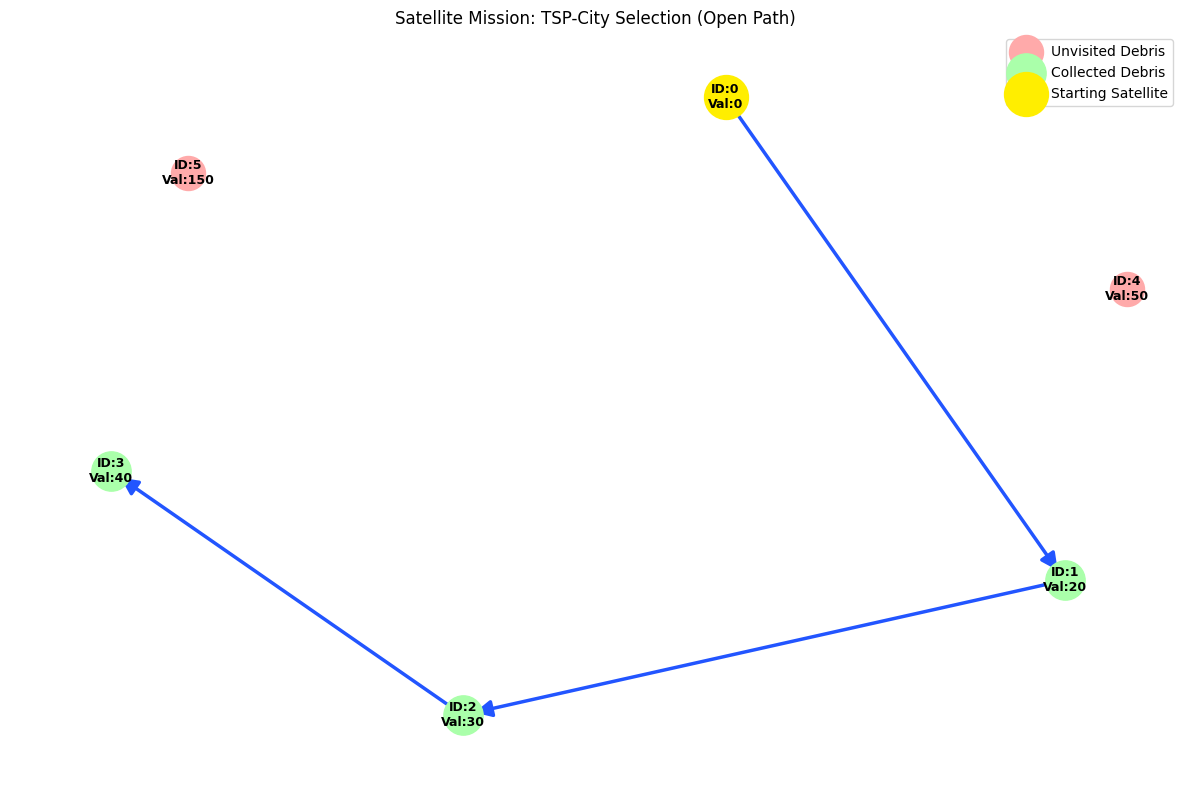

In [81]:
dist_mat = [
    [0,  12, 30, 50, 75, 95],
    [12, 0,  12, 35, 60, 85],
    [30, 12, 0,  12, 40, 65],
    [50, 35, 12, 0,  12, 40],
    [75, 60, 40, 12, 0,  12],
    [95, 85, 65, 40, 12, 0]
]

vals = [0, 20, 30, 40, 50, 150]

# Fuel Limit
L_limit = 40

result_tour = solve_tsp_city_selection(dist_mat, vals, L_limit)

plot_full_network_graph(dist_mat, vals)

if result_tour:
    plot_debris_graph(dist_mat, result_tour, vals)
else:
  print("No feasible solution found")